In [1]:
from training_libs_research import retrievePytorchDetectionLibs
retrievePytorchDetectionLibs()

In [2]:
from inference_training_research import Configuration, ImageDataset
from inference_training_research import initCudaEnvironment, createTransforms
from inference_training_research import drawImageAndFeatureMasks
from inference_training_research import exportOnnxModel, writeONNXMeta, loadONNX
from inference_training_research import trainModel, saveModel, loadModel
from inference_training_research import createModelInstance, testInference

In [3]:
initCudaEnvironment(numCudaDevices=1,
                    visibleCudaDevices="0",
                    clearCudaDeviceCount=False)

In [4]:
# train on the GPU or on the CPU, if a GPU is not available
config = Configuration()
print("Device: " + str(config.device))

trainDirectory = "../OnderzoekDataSubset/Train"
testDirectory = "../OnderzoekDataSubset/Test"

config.setDatasetPaths(trainPath=trainDirectory, testPath=testDirectory)
config.setFilePrefix("")
config.setModelName("mytrainedmodel")
config.setInputSizes(inputWidth=250, inputHeight=250)
config.setInputCellSize(cellSizeM=0.25, minCellSizeM=0.1, maxCellSizeM=0.5)

config.setVersion(20250121)

print("Version: " + str(config.version))

config.setModelInfo(channels=3, numClasses=2+1,  # (1 + background)
                    bboxOverlap=True, bboxPerImage=250, reuseModel=False)
config.setEpochs(5)

description = "Model description"
config.setOnnxInfo(producer="Tygron", description=description)

config.addLegendEntry("Background", 0, "#00000000")
config.addLegendEntry("Label name 1", 1, "#00ffbf")
config.addLegendEntry("Label name 2", 2, "#12d900")

config.setOnnxMetaData(scoreThreshold=0.2,
                       maskThreshold=0.3,
                       strideFraction=0.5)

config.setTensorInfo(tensorName='input_A:RGB_normalized', batchAmount=1)
trainingDataset = ImageDataset(config, True, createTransforms(True))
testDataset = ImageDataset(config, False, createTransforms(False))

print("Train Image count: "+str(trainingDataset.__len__()))
print("Test Image count: "+str(testDataset.__len__()))

if not trainingDataset.validateFiles(False):
    print("Inconsistent training dataset ")
    trainingDataset.validateFiles(True)

if not testDataset.validateFiles(False):
    print("Inconsistent test dataset ")
    testDataset.validateFiles(True)

print("Pytorch model name " + config.getPytorchModelFileName())
print("Onnx file name " + config.getOnnxFileName())

Device: cpu
Version: 20250121
Train Image count: 300
Test Image count: 450
Inconsistent training dataset 
mask is missing for image ../OnderzoekDataSubset/Train\0_image.png
labels are missing for image ../OnderzoekDataSubset/Train\0_image.png
mask is missing for image ../OnderzoekDataSubset/Train\100_image.png
labels are missing for image ../OnderzoekDataSubset/Train\100_image.png
mask is missing for image ../OnderzoekDataSubset/Train\101_image.png
labels are missing for image ../OnderzoekDataSubset/Train\101_image.png
mask is missing for image ../OnderzoekDataSubset/Train\102_image.png
labels are missing for image ../OnderzoekDataSubset/Train\102_image.png
mask is missing for image ../OnderzoekDataSubset/Train\103_image.png
labels are missing for image ../OnderzoekDataSubset/Train\103_image.png
mask is missing for image ../OnderzoekDataSubset/Train\104_image.png
labels are missing for image ../OnderzoekDataSubset/Train\104_image.png
mask is missing for image ../OnderzoekDataSubset/Tra

[1]


<Figure size 3200x1600 with 0 Axes>

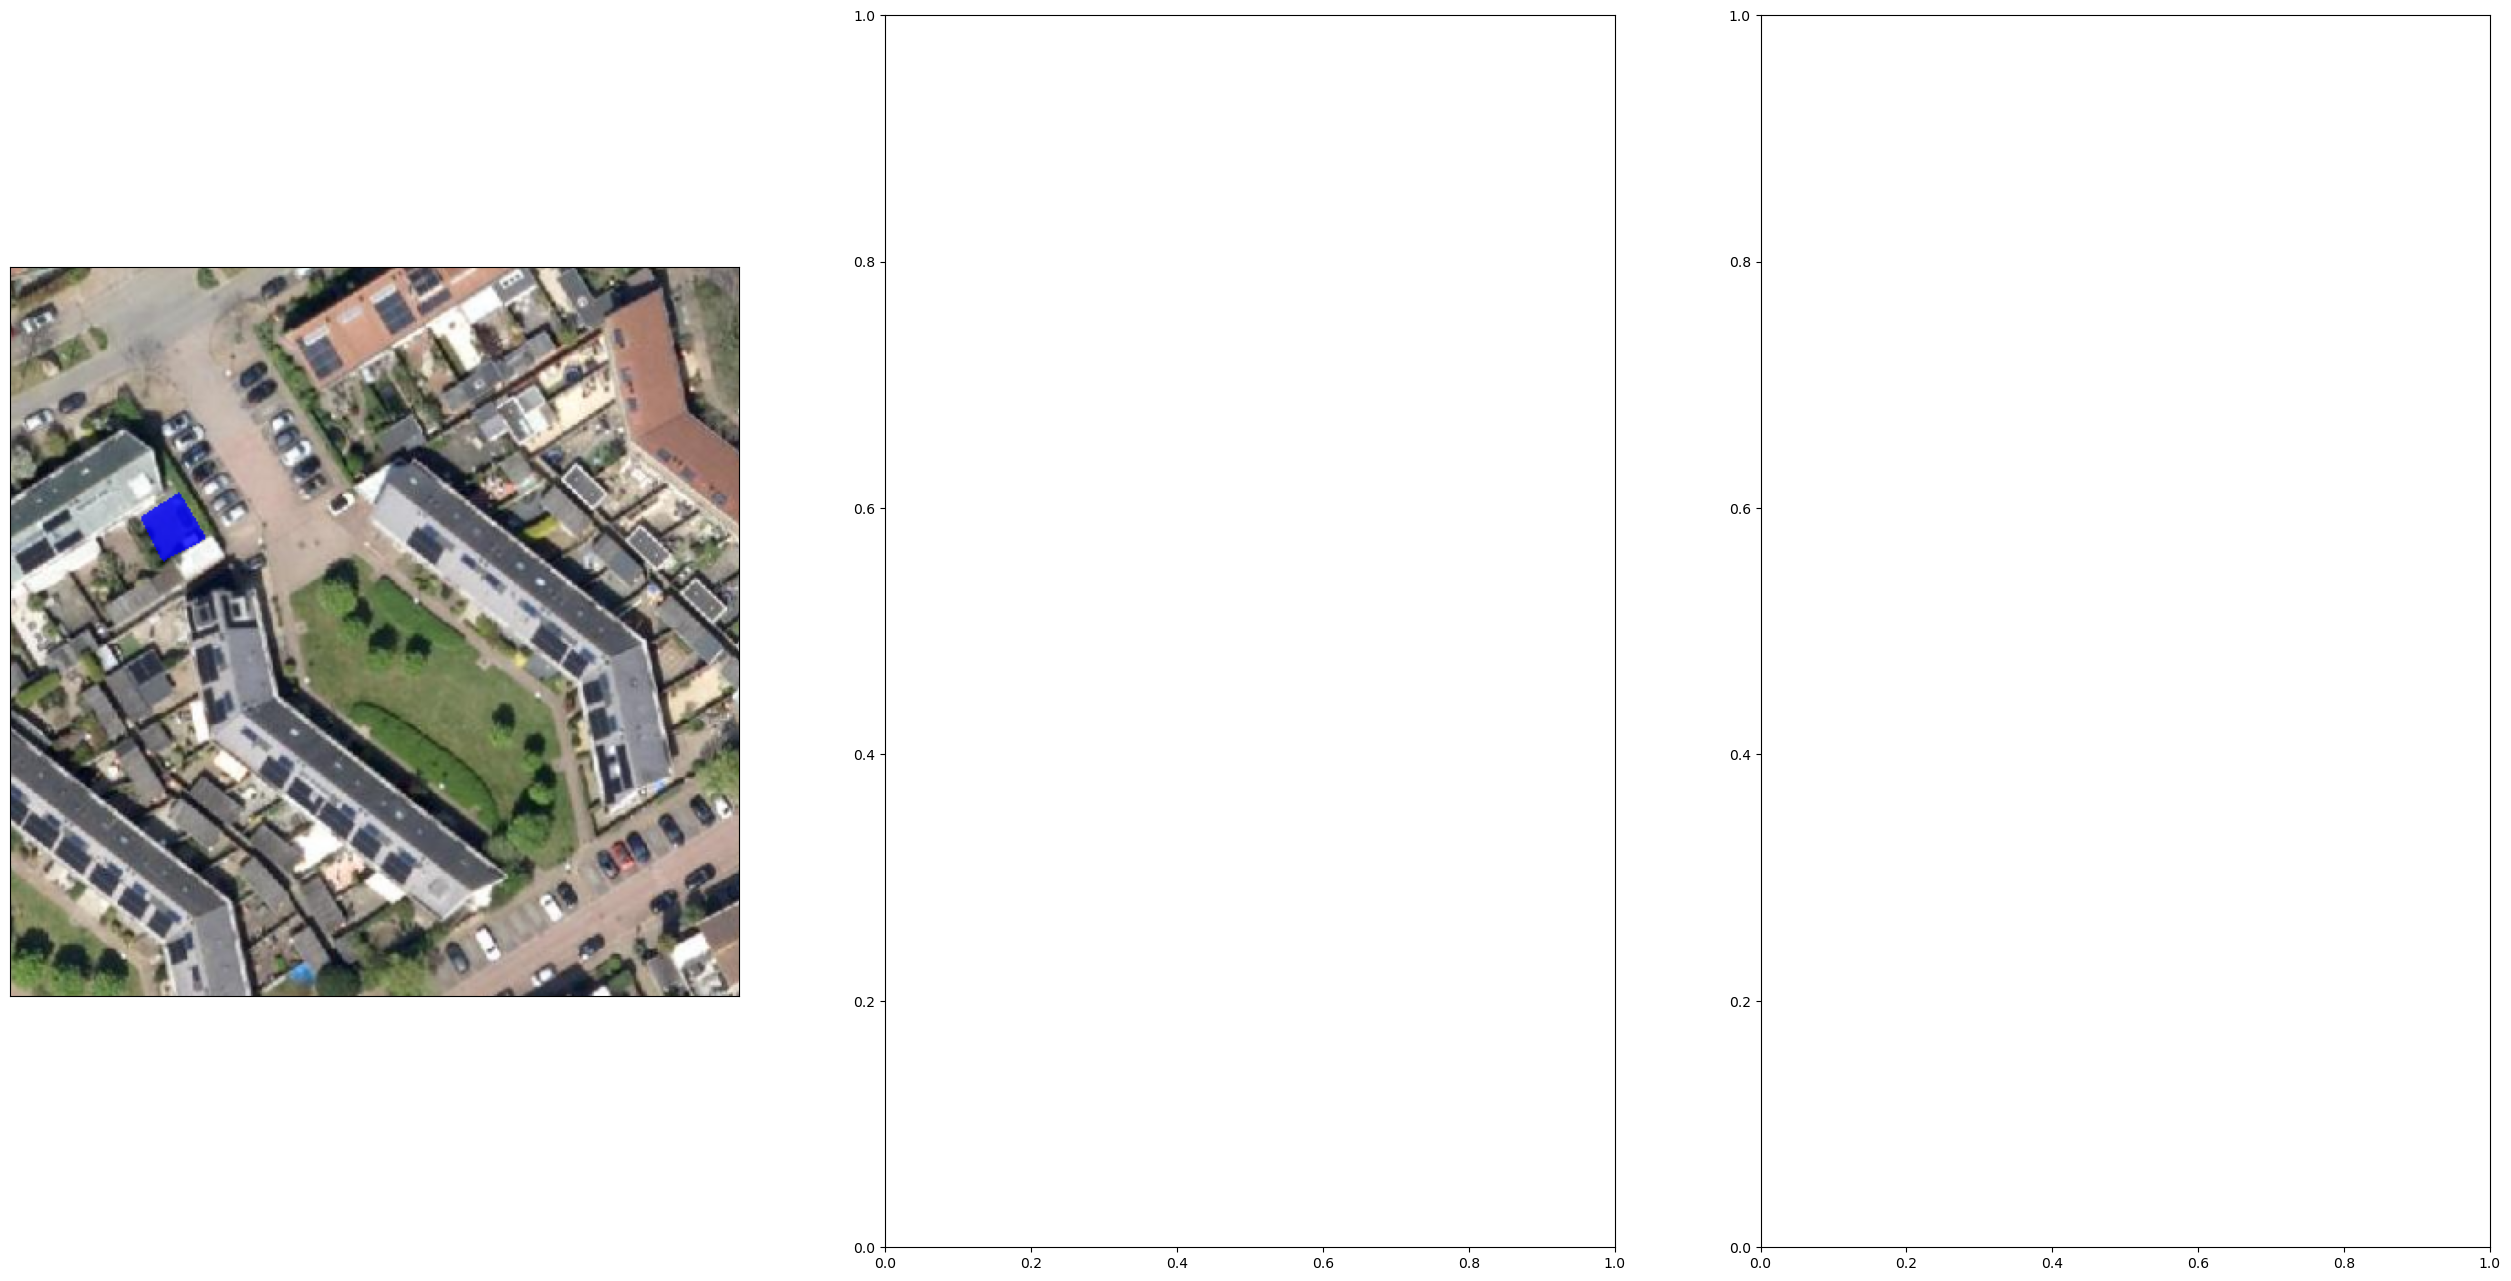

<Figure size 3200x1600 with 0 Axes>

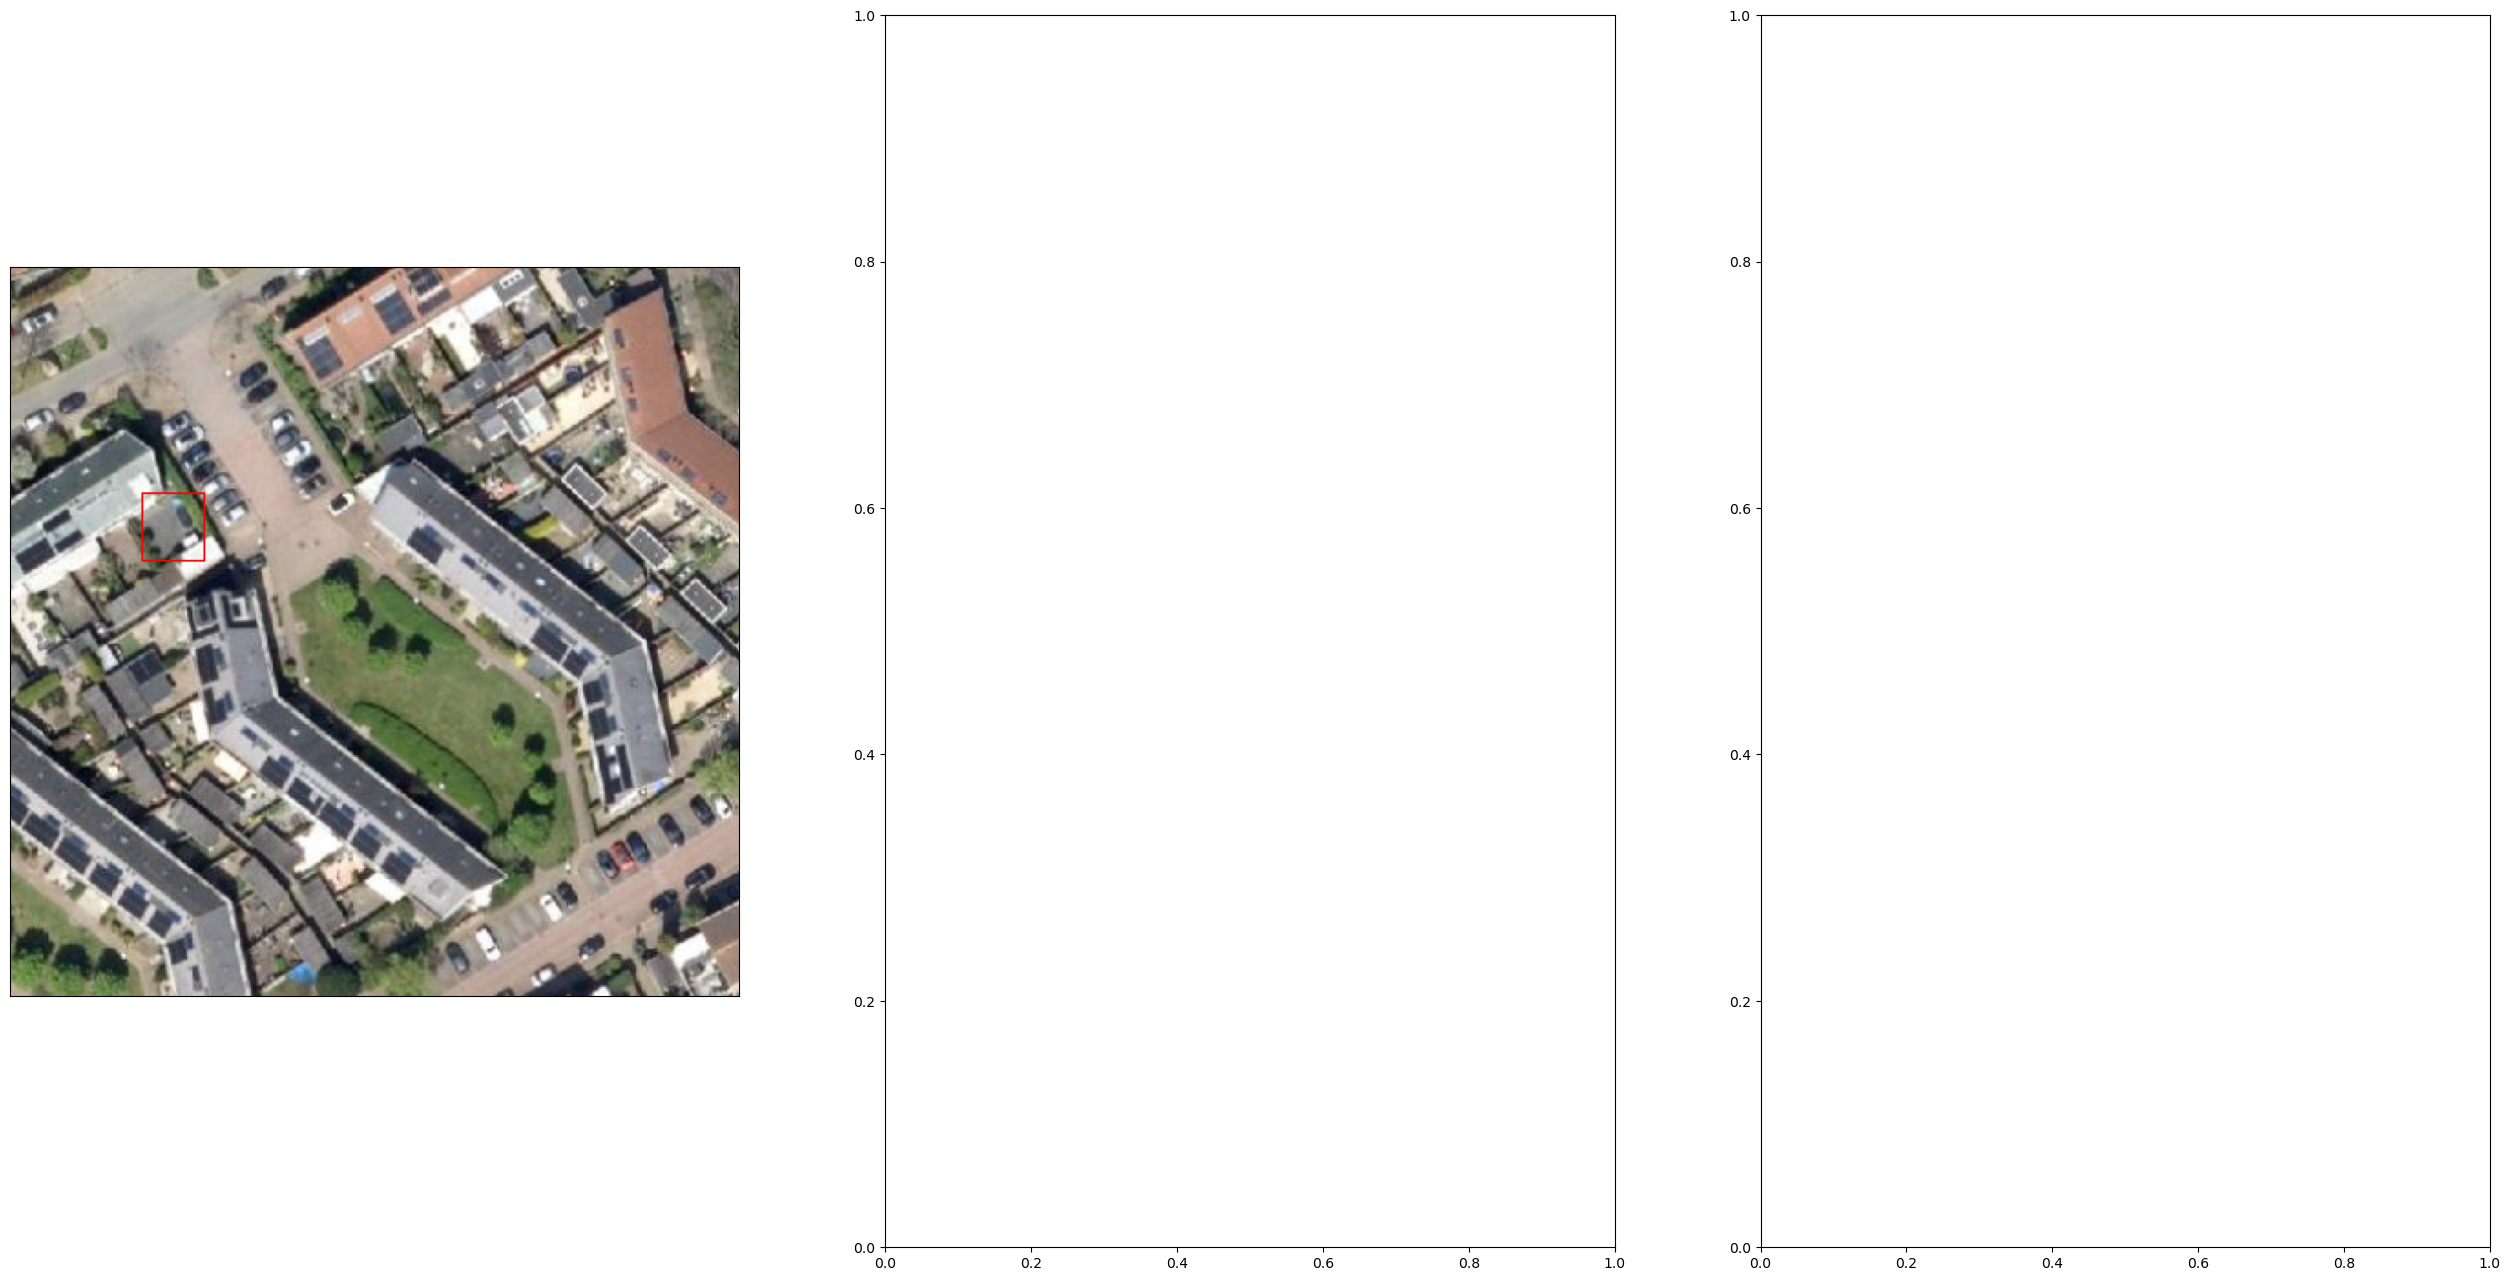

In [5]:
imageNumber = 5
print(trainingDataset.getLabelList(imageNumber))
drawImageAndFeatureMasks(config, trainingDataset, imageNumber)

In [6]:
loadExistingModel = False

if loadExistingModel:
    model = createModelInstance(config)
    loadModel(config, model, path=config.getPytorchModelFileName())

else:
    model = trainModel(config, trainingDataset, testDataset)
    saveModel(config, model, path=config.getPytorchModelFileName())

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\tiess/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100.0%


Detections per image 250
in features mask: 256


C:\Users\tiess\PycharmProjects\Tygron\ModelResearch\MaskRCNN\engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/150]  eta: 0:29:31  lr: 0.000039  loss: 3.8087 (3.8087)  loss_classifier: 0.9481 (0.9481)  loss_box_reg: 0.1533 (0.1533)  loss_mask: 1.3216 (1.3216)  loss_objectness: 1.2550 (1.2550)  loss_rpn_box_reg: 0.1306 (0.1306)  time: 11.8095  data: 0.0880
Epoch: [0]  [ 10/150]  eta: 0:23:42  lr: 0.000374  loss: 2.3273 (2.4992)  loss_classifier: 0.7309 (0.6834)  loss_box_reg: 0.1265 (0.1236)  loss_mask: 1.0198 (1.0456)  loss_objectness: 0.2442 (0.5686)  loss_rpn_box_reg: 0.0383 (0.0780)  time: 10.1628  data: 0.0693
Epoch: [0]  [ 20/150]  eta: 0:21:26  lr: 0.000709  loss: 1.6048 (2.1493)  loss_classifier: 0.3551 (0.4652)  loss_box_reg: 0.1065 (0.1256)  loss_mask: 0.7555 (0.8799)  loss_objectness: 0.2667 (0.5486)  loss_rpn_box_reg: 0.0323 (0.1300)  time: 9.8011  data: 0.0657
Epoch: [0]  [ 30/150]  eta: 0:20:19  lr: 0.001044  loss: 1.2484 (1.8453)  loss_classifier: 0.1997 (0.3859)  loss_box_reg: 0.1057 (0.1259)  loss_mask: 0.6194 (0.7792)  loss_objectness: 0.2438 (0.4391)  loss_rpn

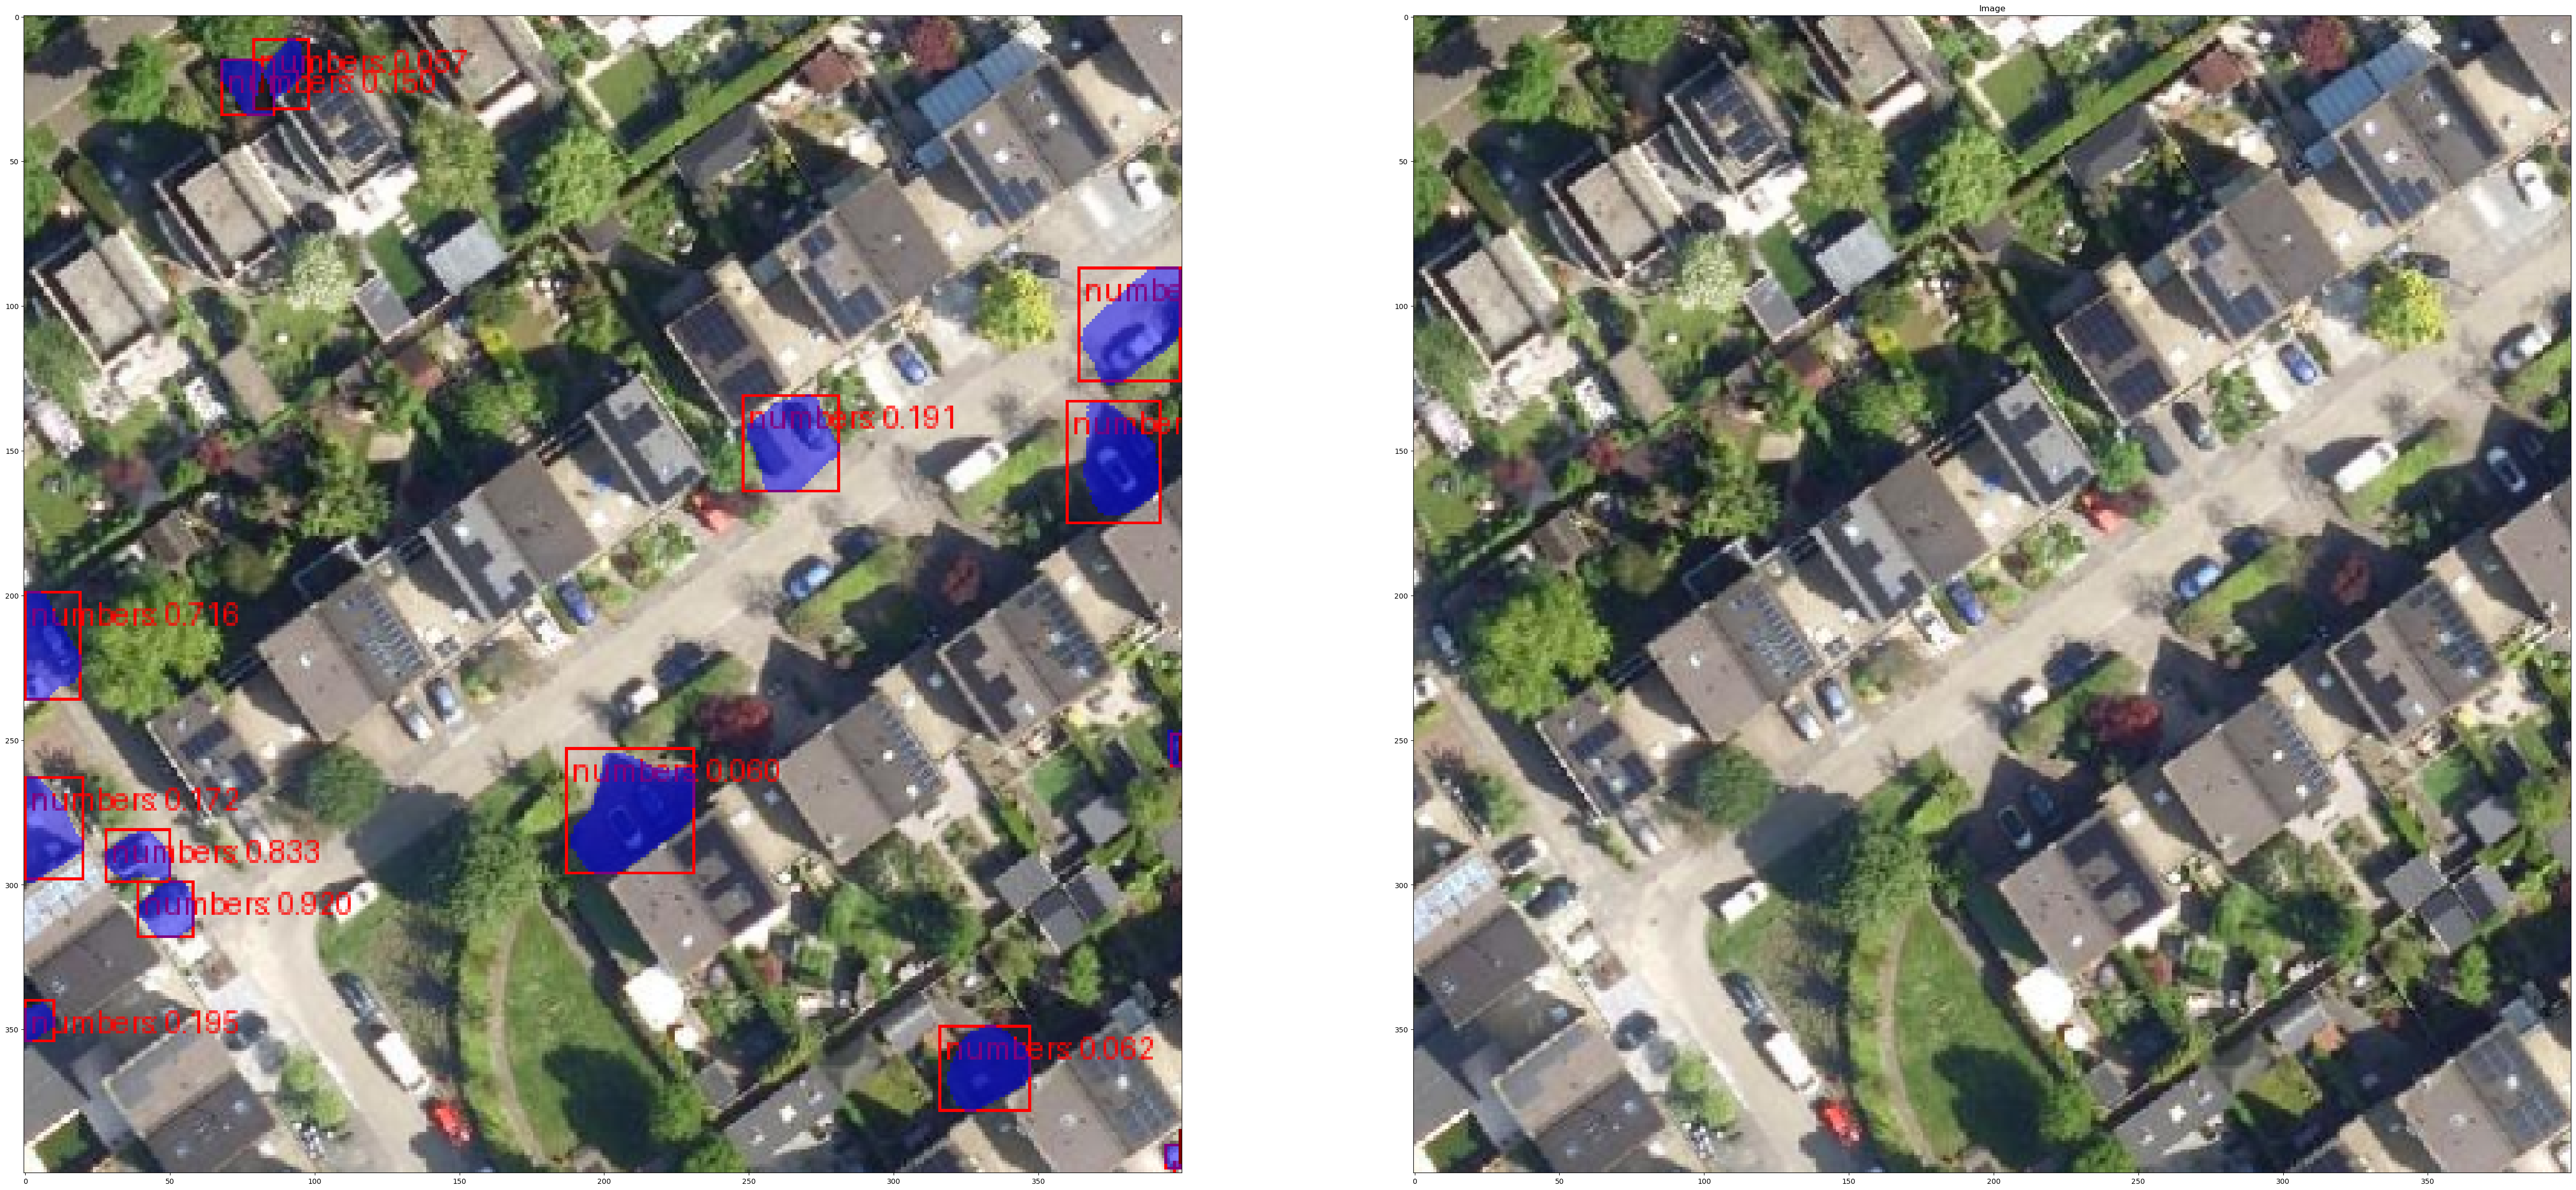

In [7]:
model.eval()
testPrediction = testInference(config, model=model,
                               dataset=testDataset, imageNumber=88)

In [8]:
exportOnnxModel(config, model)

C:\Users\tiess\anaconda3\envs\tygronai\Lib\site-packages\torch\nn\functional.py:4511: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  * torch.tensor(scale_factors[i], dtype=torch.float32)
C:\Users\tiess\anaconda3\envs\tygronai\Lib\site-packages\torchvision\ops\boxes.py:166: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes_x = torch.min(boxes_x, torch.tensor(width, dtype=boxes.dtype, device=boxes.device))
C:\Users\tiess\anaconda3\envs\tygronai\Lib\site-packages\torchvision\ops\boxes.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bo

In [9]:
writeONNXMeta(config)

In [10]:
    onnx_model = loadONNX(config)
    print(f"metadata_props={onnx_model.metadata_props}")

metadata_props=[key: "VERSION"
value: "20250121"
, key: "DESCRIPTION"
value: "Model description"
, key: "PRODUCER"
value: "Tygron"
, key: "MIN_CELL_SIZE_M"
value: "0.25"
, key: "MAX_CELL_SIZE_M"
value: "0.25"
, key: "MASK_THRESHOLD"
value: "0.3"
, key: "SCORE_THRESHOLD"
value: "0.2"
, key: "INFERENCE_MODE"
value: "1"
, key: "BOX_OVERLAP"
value: "1"
, key: "STRIDE_FRACTION"
value: "0.5"
, key: "MAX_GT_INSTANCES"
value: "250"
, key: "LEGEND_NAMES"
value: "Background, Label name 1, Label name 2"
, key: "LEGEND_VALUES"
value: "0, 1, 2"
, key: "LEGEND_COLORS"
value: "#00000000, #00ffbf, #12d900"
]
